# Yeti Travel Agency — Customer Churn Prediction

## Goal
Predict whether a school-group customer will be retained (come back next year) given data from three internal departments: Sales, Finance, CRM.
Binary classification. Target: `Retained` (1 = retained, 0 = churned).

## Approach
Merge the three datasets, clean and engineer features, fit 9 classifier families with tuned hyperparameters (GridSearchCV, cv=5, scoring='f1'), select the winner by validation F1, refit on the full labelled dataset, and predict on the held-out test set.

## Key design choices
- **Merge strategy:** inner join on extracted numeric ID for training (3 095 rows); positional `pd.concat` for the test set — preserves all 630 test records (mandatory for submission).
- `RobustScaler` instead of `StandardScaler` — less sensitive to the heavy outliers in `FPP`, `Total_Pax`, `SPR_Group_Revenue`.
- `OneHotEncoder` for categoricals — correct for distance-based and linear models.
- Engineered date-derived features: `Days_System_to_Departure`, `RPL_Window_Days`, `Departure_Month_Num`.
- `ColumnTransformer` pipeline fitted **strictly on `X_train`** — no leakage into validation or submission.
- 75/25 stratified split preserving the ≈60/40 class balance.
- `GaussianNB` included as an illustrative baseline only; its failure after one-hot encoding is expected and documented.


## 1. Imports & configuration

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)

RANDOM_STATE = 7
pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')

## 2. Load the six CSVs

Three model (training) files with a `Retained` target, three matching test files without it.
Load everything as strings to handle European-decimal formatting manually later.

In [ ]:
sales        = pd.read_csv('sales_model.csv',   dtype=str)
finance      = pd.read_csv('finance_model.csv', dtype=str)
crm          = pd.read_csv('crm_model.csv',     dtype=str)
sales_test   = pd.read_csv('sales_test.csv',    dtype=str)
finance_test = pd.read_csv('finance_test.csv',  dtype=str)
crm_test     = pd.read_csv('crm_test.csv',      dtype=str)

print("Train shapes:", sales.shape, finance.shape, crm.shape)
print("Test shapes: ", sales_test.shape, finance_test.shape, crm_test.shape)
print("\nTarget balance:")
print(sales['Retained'].value_counts(normalize=True).round(3))

Train shapes: (4153, 24) (4151, 12) (4148, 20)
Test shapes:  (630, 24) (630, 12) (630, 20)

Target balance:
Retained
1    0.607
0    0.393
Name: proportion, dtype: float64


## 3. ID normalisation

Each department uses its own coding scheme (`CC1387A`, `1389`/`CP1021`, `01000I`).
For the **training set** we attempt an inner join on the embedded numeric substring — this keeps only records matched across all three systems (3 095 / 4 153 rows).

> ⚠️ **Important caveat:** The numeric substring match is a heuristic, not a verified shared key.
> For the **test set** (all 630 records perfectly aligned across files) we use a positional
> `pd.concat` to guarantee the full submission. Both approaches are shown below.


In [ ]:
def to_num_eu(s):
    """Convert string series with possibly European decimal format ('0,123') to float."""
    return pd.to_numeric(s.astype(str).str.replace(',', '.', regex=False), errors='coerce')

def extract_id_num(s):
    """Extract digit-only core of an ID, keep as string."""""
    return s.astype(str).str.extract(r'(\d+)')[0]

# ── Numeric ID for training inner-join ────────────────────────────────────────
for df in [sales, finance, crm]:
    for col in ['ID_SALES', 'ID_FINANCE', 'ID_CRM']:
        if col in df.columns:
            df['ID_num'] = extract_id_num(df[col])
            break

print("Unique ID_num — train:", sales['ID_num'].nunique(),
      finance['ID_num'].nunique(), crm['ID_num'].nunique())


Unique ID_num — train: 4153 4151 4145


## 4. Merge the three datasets

### Training set — inner join on numeric ID
Keeps only records present in all three departments (3 095 / 4 153 rows, ~74.5%).
The dropped rows are clients whose records were not fully synced across departments;
their absence biases the training set slightly but is preferable to imputing entire
feature blocks with no departmental signal.

### Test set — positional concat (all 630 rows)
The three test files are perfectly row-aligned (confirmed: all 630 rows, zero cross-file
NaN). A positional concat retains every record, which is **required** for the submission.


In [ ]:
# ── Training set: inner join on shared numeric ID ────────────────────────────
df_train = sales.merge(finance, on='ID_num', how='inner', suffixes=('', '_fin'))
df_train = df_train.merge(crm,   on='ID_num', how='inner', suffixes=('', '_crm'))

print(f"Train after 3-way inner join: {df_train.shape}")
print(f"Retained balance: {df_train['Retained'].value_counts(normalize=True).round(3).to_dict()}")

# ── Test set: positional concat — preserves all 630 records ──────────────────
# The three test files are row-aligned: row i in sales_test = row i in finance_test = row i in crm_test.
# We drop department-specific ID cols from finance/crm to avoid duplicate columns.
df_test = pd.concat([
    sales_test.reset_index(drop=True),
    finance_test.drop(columns=['ID_FINANCE'], errors='ignore').reset_index(drop=True),
    crm_test.drop(columns=['ID_CRM'], errors='ignore').reset_index(drop=True),
], axis=1)

# Drop the spurious trailing column present in sales_test
df_test.drop(columns=['Unnamed: 23'], inplace=True, errors='ignore')

print(f"Test  after positional concat: {df_test.shape}  (all 630 records preserved)")


Train after 3-way inner join: (3095, 57)
Retained balance: {'1': 0.588, '0': 0.412}
Test  after positional concat: (630, 53)  (all 630 records preserved)


## 5. Numeric conversion + date feature engineering

- Cast European-format numbers to proper floats.
- Engineer three date-derived features, then drop raw date columns (ML models don't handle raw timestamps well).

In [ ]:
numeric_cols = [
    'From_Grade', 'To_Grade', 'Days', 'Cancelled_Pax', 'Total_Discount_Pax',
    'FPP', 'Total_Pax', 'FPP_to_School_enrollment',
    'Tuition', 'FRP_Active', 'FRP_Cancelled', 'FRP_Take_up_percent_',
    'EZ_Pay_Take_Up_Rate', 'SPR_Group_Revenue', 'FPP_to_PAX', 'Num_of_Non_FPP_PAX',
    'MDR_Low_Grade', 'MDR_High_Grade', 'Total_School_Enrollment',
    'NumberOfMeetingswithParents',
    'DifferenceTraveltoFirstMeeting', 'DifferenceTraveltoLastMeeting',
]
for df in [df_train, df_test]:
    for col in numeric_cols:
        if col in df.columns:
            df[col] = to_num_eu(df[col])

df_train['Retained'] = pd.to_numeric(df_train['Retained'], errors='coerce').astype('Int64')

In [ ]:
date_cols = ['Departure_Date', 'Return_Date', 'Early_RPL', 'Latest_RPL',
             'Initial_System_Date', 'Deposit_Date', 'FirstMeeting', 'LastMeeting']

for df in [df_train, df_test]:
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    df['Days_System_to_Departure'] = (df['Departure_Date'] - df['Initial_System_Date']).dt.days
    df['RPL_Window_Days']          = (df['Latest_RPL']     - df['Early_RPL']).dt.days
    df['Departure_Month_Num']      = df['Departure_Date'].dt.month
    df.drop(columns=[c for c in date_cols if c in df.columns], inplace=True)

print("After cleaning:", df_train.shape, df_test.shape)
df_train.head(3)

After cleaning: (3095, 52) (630, 48)


,ID_SALES,Program_Code,From_Grade,To_Grade,Group_State,Days,Travel_Type,Cancelled_Pax,Total_Discount_Pax,SPR_Product_Type,FPP,Total_Pax,DepartureMonth,GroupGradeTypeLow,GroupGradeTypeHigh,GroupGradeType,MajorProgramCode,FPP_to_School_enrollment,Retained,ID_num,ID_FINANCE,Special_Pay,Tuition,FRP_Active,FRP_Cancelled,FRP_Take_up_percent_,EZ_Pay_Take_Up_Rate,School_Sponsor,SPR_Group_Revenue,FPP_to_PAX,Num_of_Non_FPP_PAX,ID_CRM,Poverty_Code,Region,CRM_Segment,School_Type,Parent_Meeting_Flag,MDR_Low_Grade,MDR_High_Grade,Total_School_Enrollment,Income_Level,SPR_New_Existing,NumberOfMeetingswithParents,DifferenceTraveltoFirstMeeting,DifferenceTraveltoLastMeeting,SchoolGradeTypeLow,SchoolGradeTypeHigh,SchoolGradeType,SchoolSizeIndicator,Days_System_to_Departure,RPL_Window_Days,Departure_Month_Num
0,HC1016A,HC,5.0,6.0,CA,27,A,5,2,East Coast,30,38,January,K,Middle,K->Middle,H,0.047104,1,1016,NA1016,NaN,2165,8,3,0.247462,0.097408,0,2215,0.894883,3,B1016K,B,Southern California,5,PUBLIC,1,NaN,7,705,K,1,1,222.0,216.0,Middle,Middle,Middle->Middle,M-L,215.0,NaN,4
1,HC101A,HC,9.0,9.0,TX,22,A,5,1,East Coast,8,11,January,Middle,Middle,Middle->Middle,H,0.010041,1,101,NA101,NaN,1671,9,5,1.007040,0.506851,0,1743,0.863140,1,B101L,B,Houston,11,PUBLIC,1,6.0,8,856,L,0,1,251.0,248.0,Middle,Middle,Middle->Middle,L,423.0,145.0,6
2,HC1029A,HC,10.0,10.0,TX,14,A,7,5,East Coast,54,48,January,Middle,Middle,Middle->Middle,H,0.061022,1,1029,NA1029,NaN,1657,34,6,0.717598,0.232526,0,1668,0.886276,4,C1029I,C,Houston,10,PUBLIC,1,7.0,8,730,I,1,2,438.0,247.0,Middle,Middle,Middle->Middle,M-L,459.0,152.0,6


## 6. Quick EDA

Target distribution, missing values, and a handful of exploratory plots.

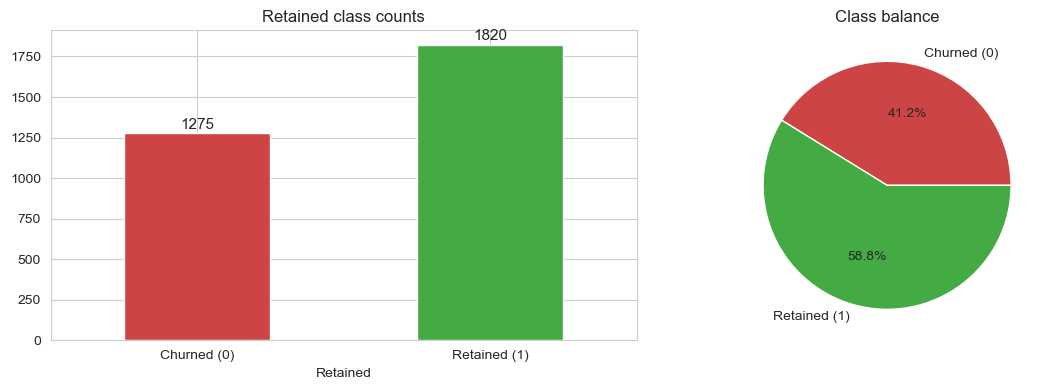

In [ ]:
 # Sort by class value (0 then 1), not by frequency
counts = df_train['Retained'].value_counts().sort_index()
labels = ['Churned (0)', 'Retained (1)']
colors = ['#c44', '#4a4']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts.plot.bar(ax=axes[0], rot=0, color=colors)
axes[0].set_title('Retained class counts')
axes[0].set_xticklabels(labels)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                 f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=11)

(counts / counts.sum()).plot.pie(
    ax=axes[1], autopct='%.1f%%', labels=labels, colors=colors
)
axes[1].set_ylabel('')
axes[1].set_title('Class balance')

plt.tight_layout()
plt.show()

In [ ]:
# Missing values in train (top 15)
miss = df_train.isna().sum().sort_values(ascending=False)
miss = miss[miss > 0].head(15)
print("Columns with most missing values:")
print(miss)

Columns with most missing values:
Special_Pay                       2592
RPL_Window_Days                    869
MDR_Low_Grade                      625
DifferenceTraveltoLastMeeting      352
DifferenceTraveltoFirstMeeting     352
To_Grade                           195
From_Grade                         161
FPP_to_School_enrollment            19
SchoolSizeIndicator                 19
Days_System_to_Departure            12
dtype: int64


In [ ]:
# Numeric feature correlation with target
num_for_corr = df_train.select_dtypes(include=['number']).copy()
corr = num_for_corr.corr()['Retained'].drop('Retained').sort_values(key=abs, ascending=False).head(15)
print("Top 15 numeric features by absolute correlation with Retained:")
print(corr.round(3))

Top 15 numeric features by absolute correlation with Retained:
FRP_Active                        0.263
FPP                               0.250
Total_Pax                         0.249
Num_of_Non_FPP_PAX                0.211
Total_Discount_Pax                0.207
MDR_High_Grade                   -0.173
FPP_to_PAX                        0.146
MDR_Low_Grade                    -0.145
SPR_Group_Revenue                -0.125
DifferenceTraveltoFirstMeeting   -0.125
Departure_Month_Num              -0.124
Tuition                          -0.122
FRP_Cancelled                     0.109
DifferenceTraveltoLastMeeting    -0.108
To_Grade                         -0.106
Name: Retained, dtype: float64


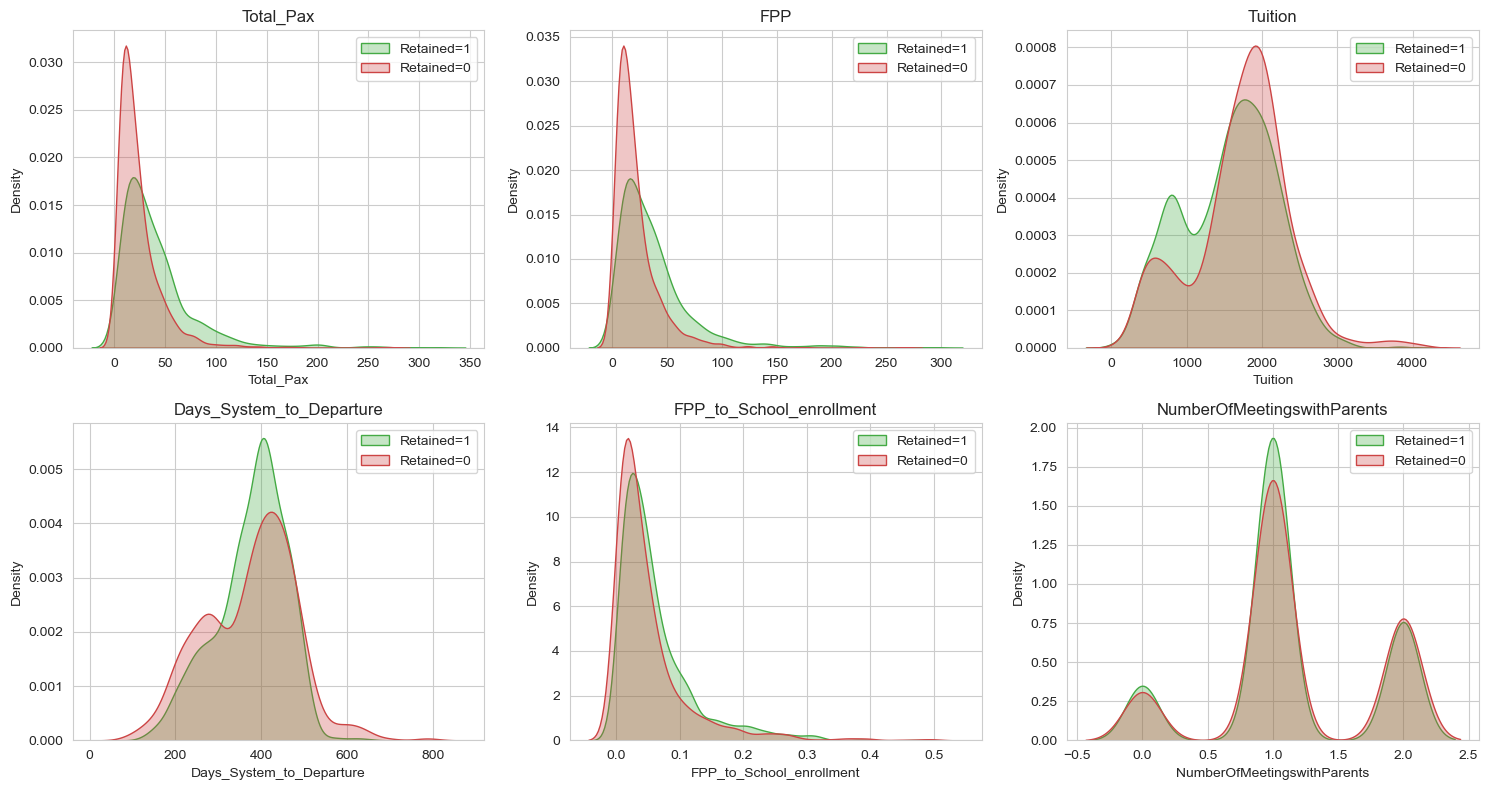

In [ ]:
# A few distributions split by target class
important = ['Total_Pax', 'FPP', 'Tuition', 'Days_System_to_Departure',
             'FPP_to_School_enrollment', 'NumberOfMeetingswithParents']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), important):
    if col in df_train.columns:
        for val, color in [(1, '#4a4'), (0, '#c44')]:
            sns.kdeplot(df_train.loc[df_train['Retained'] == val, col].dropna(),
                        ax=ax, label=f'Retained={val}', color=color, fill=True, alpha=0.3)
        ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

### Additional EDA

**Boxplot** — Shows the distribution and outliers of each numeric feature. Features with large ranges (like `SPR_Group_Revenue`) may need scaling, which is handled by the RobustScaler in our pipeline.

**Histograms** — Shows the shape of each numeric feature's distribution. Helps identify skewed features and potential data quality issues.

**Correlation Heatmap** — Shows the top 15 features most correlated with the target variable `Retained`. Features with high absolute correlation are the most predictive. Positive correlation means higher values are associated with retention, negative means the opposite.

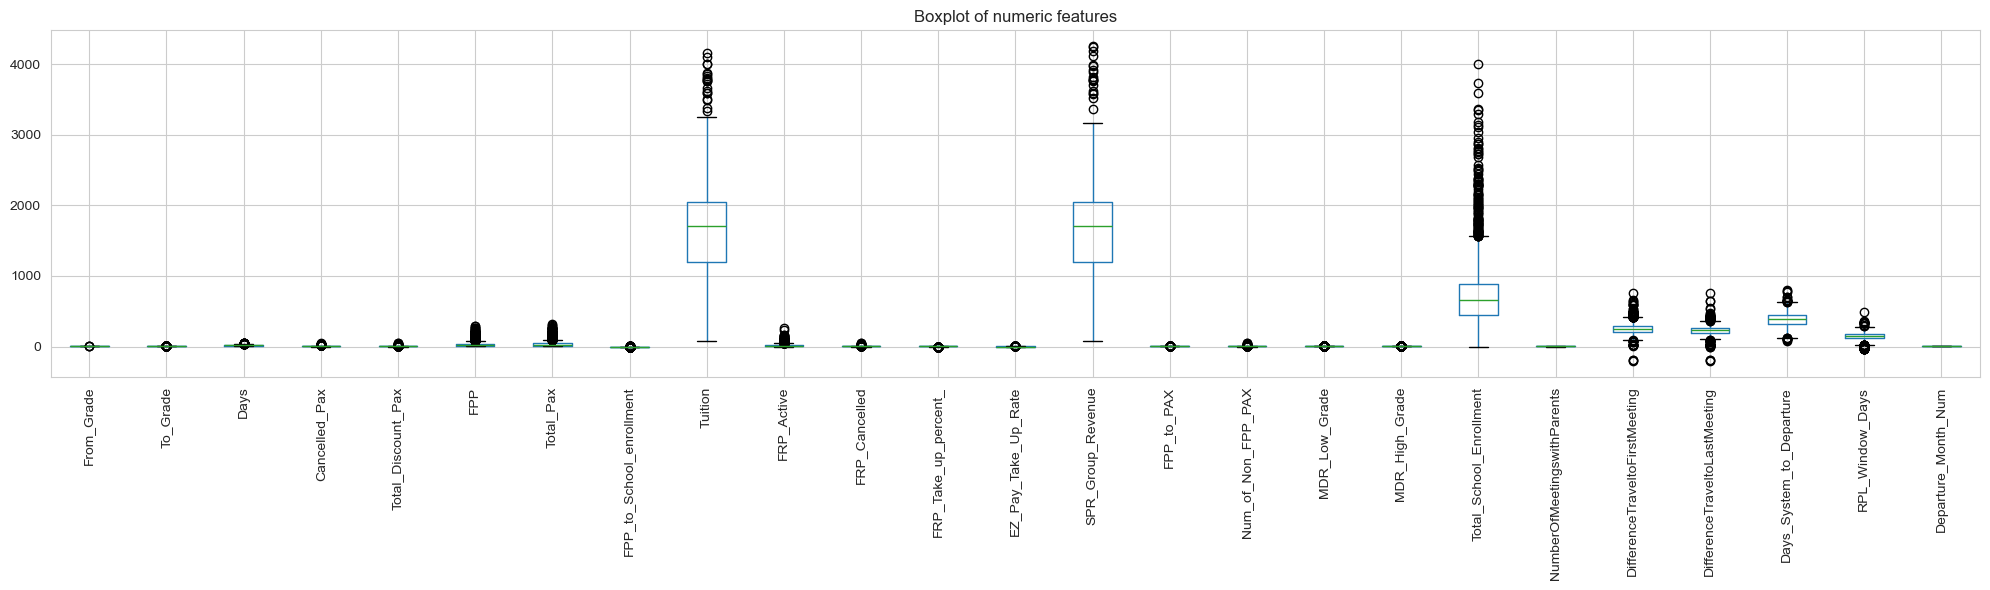

In [ ]:
df_train.select_dtypes(include='number').drop(columns=['Retained']).boxplot(rot=90, figsize=(20, 6))
plt.title('Boxplot of numeric features')
plt.tight_layout()
plt.show()

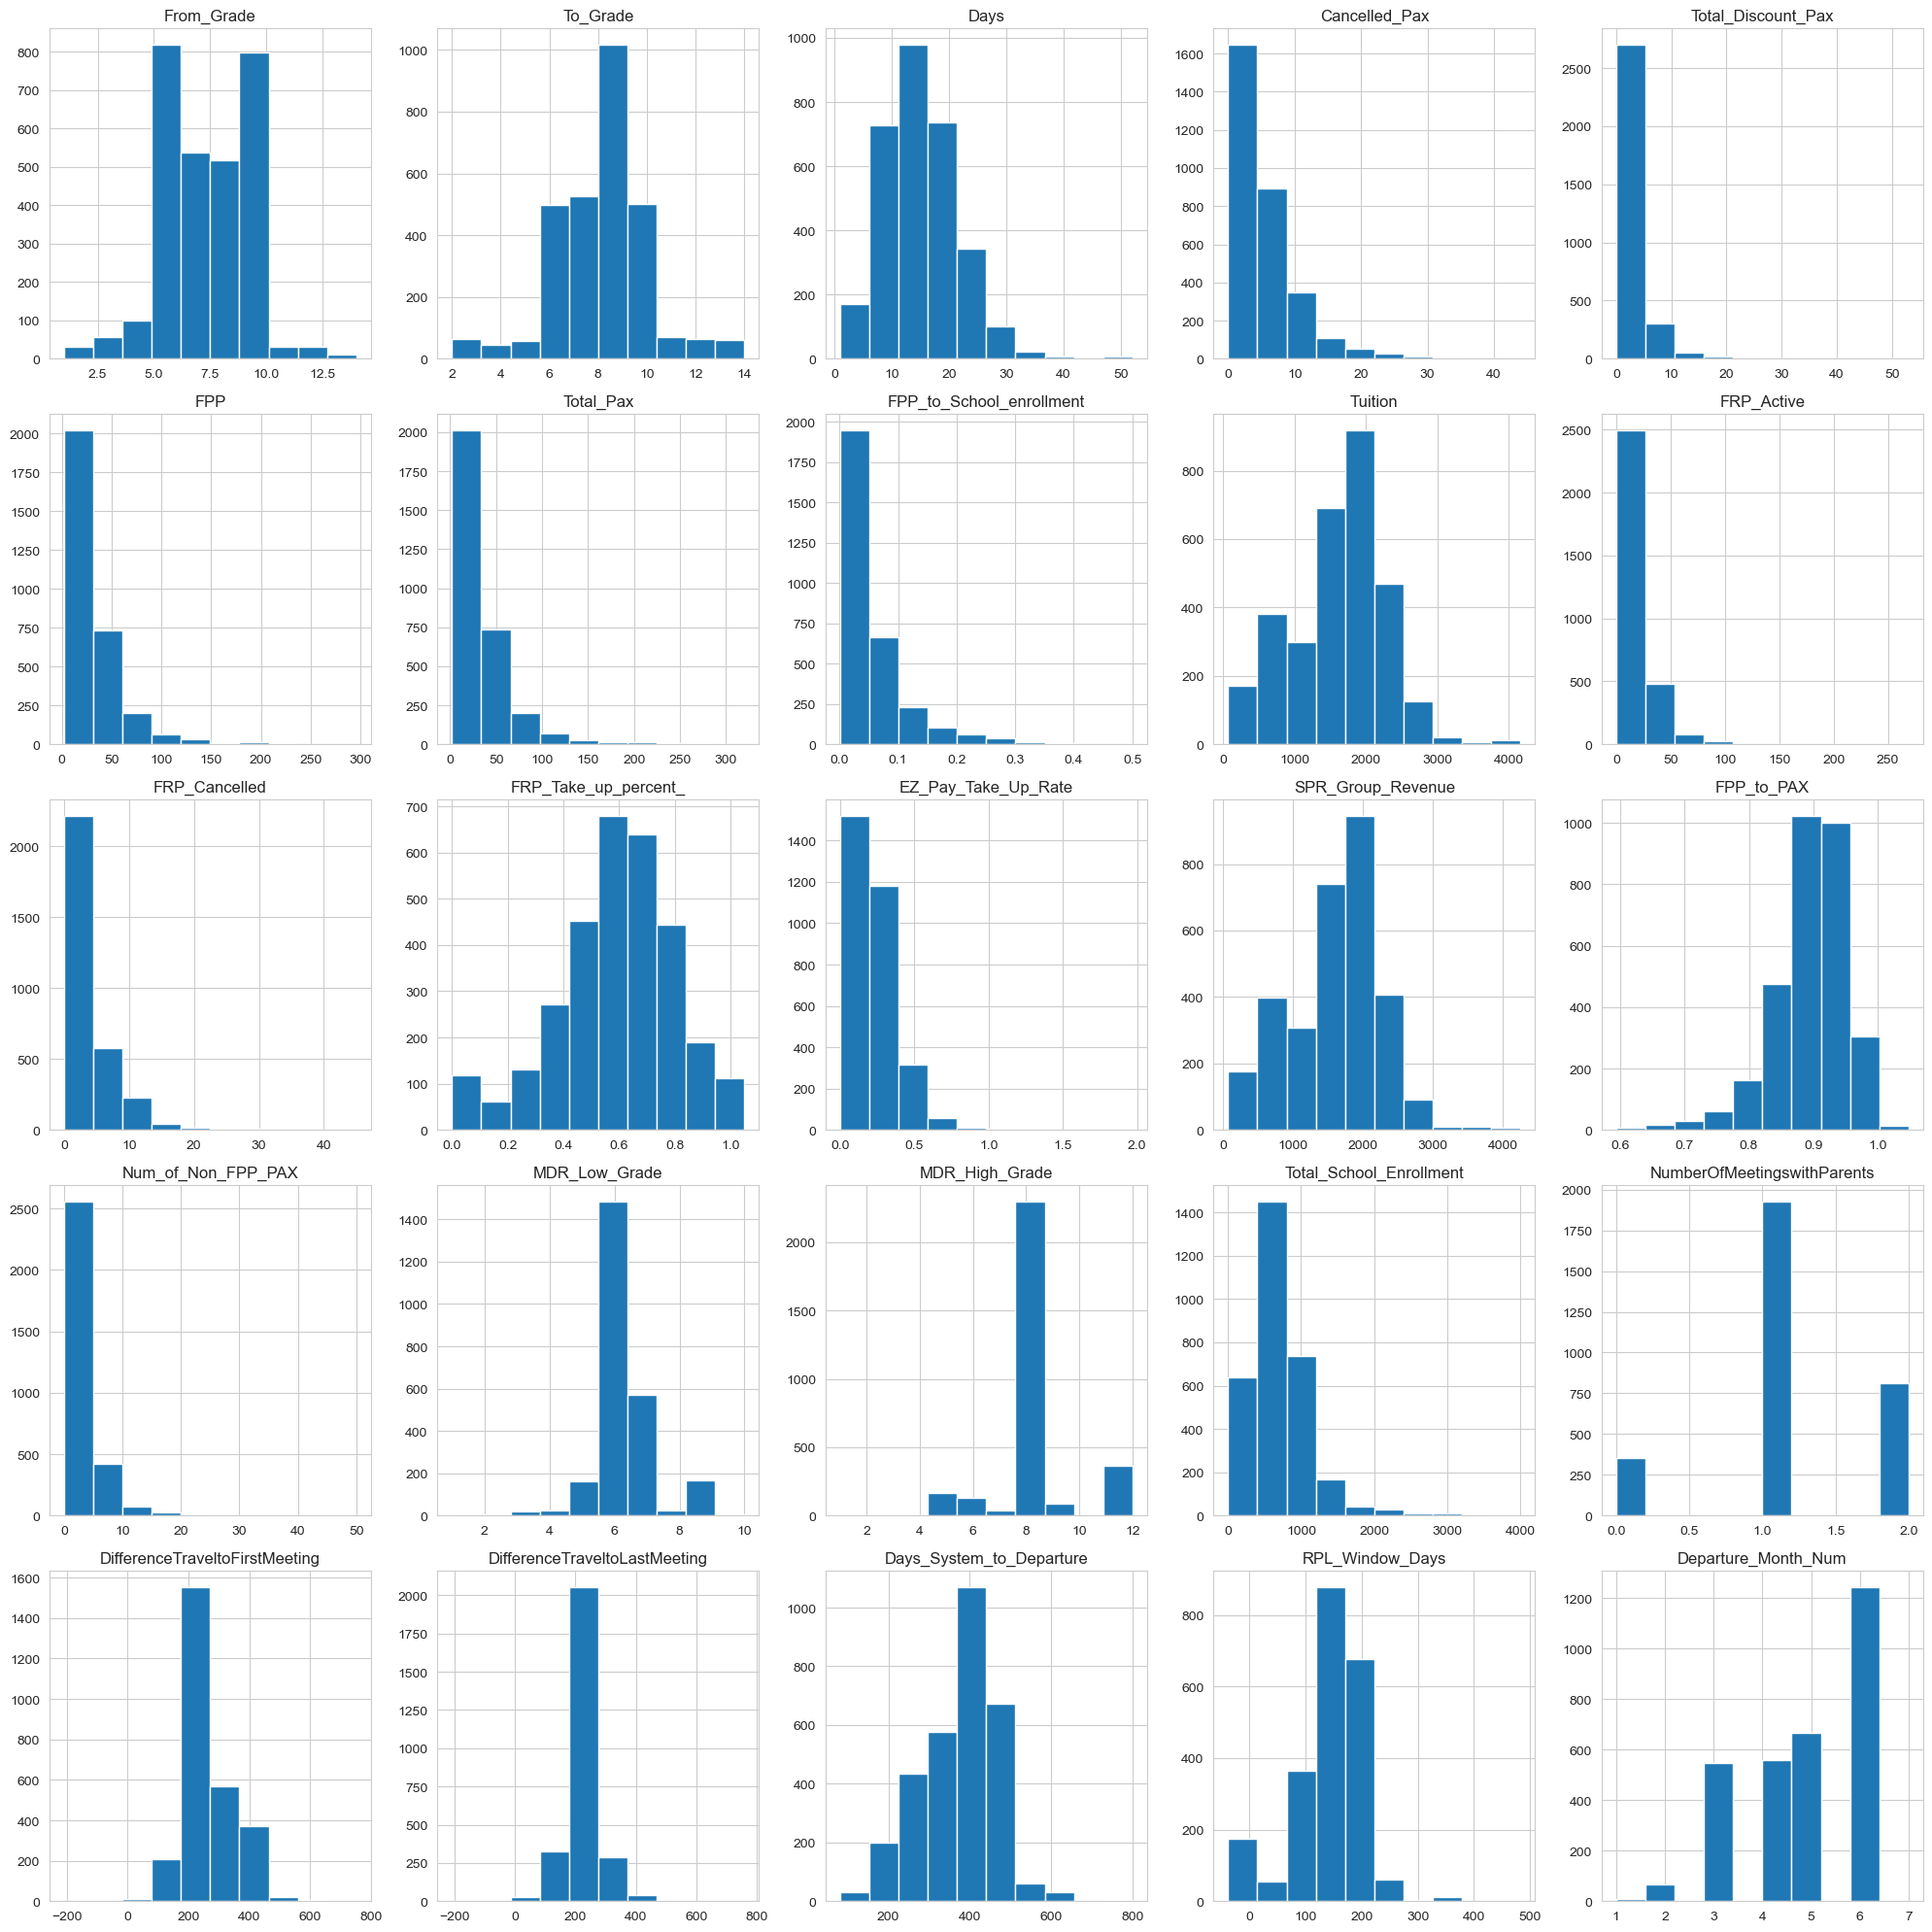

In [ ]:
df_train.select_dtypes(include='number').drop(columns=['Retained']).hist(figsize=(20, 20))
plt.tight_layout()
plt.show()

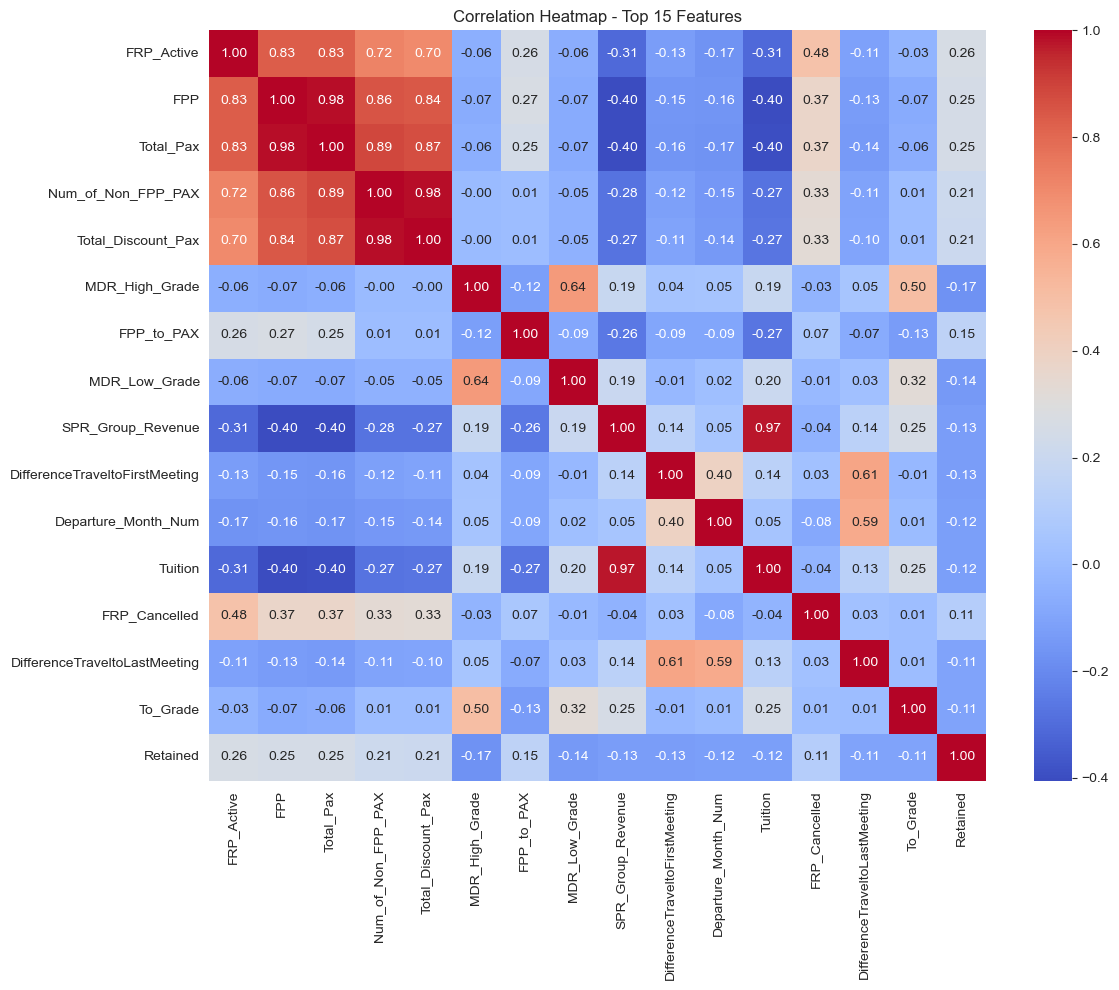

In [ ]:
num_for_corr = df_train.select_dtypes(include='number').copy()
top_features = num_for_corr.corr()['Retained'].drop('Retained').abs().sort_values(ascending=False).head(15).index.tolist()
top_features.append('Retained')

plt.figure(figsize=(12, 10))
sns.heatmap(num_for_corr[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap - Top 15 Features')
plt.tight_layout()
plt.show()

## 7. Feature/target split and train/validation split

- Drop ID columns from features.
- Keep `ID_SALES` from the test frame separately for the final submission.
- Stratified 75/25 split so both halves preserve the ~60/40 class balance.

In [ ]:
id_cols = ['ID_SALES', 'ID_FINANCE', 'ID_CRM', 'ID_num']

# ── Training features & target ────────────────────────────────────────────────
y = df_train['Retained'].astype(int)
X = df_train.drop(columns=[c for c in id_cols + ['Retained'] if c in df_train.columns])

# ── Submission features (test set) ────────────────────────────────────────────
# Preserve ID_SALES for the final CSV, then build the feature matrix.
test_ids = df_test['ID_SALES'].copy()
X_submission = df_test.drop(columns=[c for c in id_cols if c in df_test.columns])

# Align test columns to training columns (add any absent cols as NaN, drop extras).
for c in X.columns:
    if c not in X_submission.columns:
        X_submission[c] = np.nan
X_submission = X_submission[X.columns]

numeric_features     = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"X shape:          {X.shape}")
print(f"X_submission:     {X_submission.shape}  (should be 630 rows)")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical feat: {len(categorical_features)}")
assert len(test_ids) == 630, f"Expected 630 test records, got {len(test_ids)}"
print("✓ All 630 test records present")


X shape:          (3095, 47)
X_submission:     (630, 47)  (should be 630 rows)
Numeric features: 25
Categorical feat: 22
✓ All 630 test records present


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "  Val:", X_val.shape)
print(f"Target balance — full={y.mean():.3f}  train={y_train.mean():.3f}  val={y_val.mean():.3f}")

Train: (2321, 47)   Val: (774, 47)
Target balance — full=0.588  train=0.588  val=0.588


## 8. Preprocessing pipeline

Fit the imputer, scaler, and encoder **only on `X_train`**, then transform `X_val` and the submission set with the same fitted object. This is the leakage-free pattern.

- Numeric → median imputation → `RobustScaler`.
- Categorical → constant `'Missing'` imputation → `OneHotEncoder`.

In [ ]:
from sklearn.base import clone

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler()),
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline,     numeric_features),
    ('cat', categorical_pipeline, categorical_features),
])

X_train_p = preprocessor.fit_transform(X_train)
X_val_p   = preprocessor.transform(X_val)
X_sub_p   = preprocessor.transform(X_submission)

feature_names = preprocessor.get_feature_names_out()
print(f"After one-hot expansion: train={X_train_p.shape}  val={X_val_p.shape}  sub={X_sub_p.shape}")


After one-hot expansion: train=(2321, 208)  val=(774, 208)  sub=(630, 208)


## 9. Evaluation helper

Wraps fit + predict + metrics for any scikit-learn classifier.

In [ ]:
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
roc_data = {}

def evaluate(name, model, X_tr, X_v, y_tr, y_v):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_v)
    try:
        y_proba = model.predict_proba(X_v)[:, 1]
    except Exception:
        y_proba = model.decision_function(X_v) if hasattr(model, 'decision_function') else y_pred

    # Store ROC data for later
    fpr, tpr, _ = roc_curve(y_v, y_proba)
    roc_data[name] = (fpr, tpr, roc_auc_score(y_v, y_proba))

    # Train set results
    y_pred_train = model.predict(X_tr)
    print('***RESULTS ON TRAIN SET***')
    print("f1_score: ", round(f1_score(y_tr, y_pred_train), 4))
    print('---')
    print('***RESULTS ON VAL SET***')
    print(classification_report(y_v, y_pred))

    # Confusion matrix
    sns.heatmap(confusion_matrix(y_v, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.show()

    return {
        'model_name': name,
        'model':      model,
        'f1':         f1_score(y_v, y_pred),
        'accuracy':   accuracy_score(y_v, y_pred),
        'auc':        roc_auc_score(y_v, y_proba)
    }

## 10. Model 1 — K-Nearest Neighbors

Distance-based classifier. Highly sensitive to feature scaling (hence the scaler above).

***RESULTS ON TRAIN SET***
f1_score:  0.7785
---
***RESULTS ON VAL SET***
              precision    recall  f1-score   support

           0       0.75      0.38      0.50       319
           1       0.68      0.91      0.78       455

    accuracy                           0.69       774
   macro avg       0.71      0.64      0.64       774
weighted avg       0.71      0.69      0.66       774



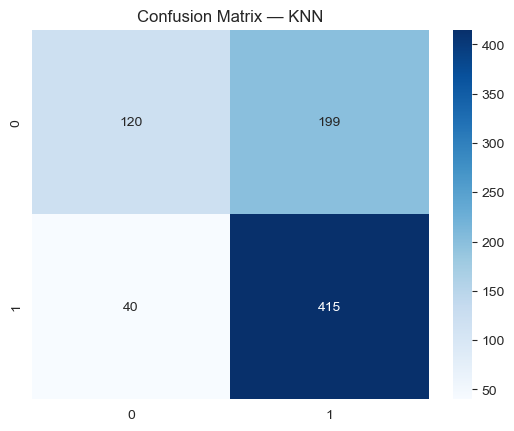

Best params: {'n_neighbors': 45, 'weights': 'uniform'}
Val F1=0.7764  Acc=0.6912  AUC=0.7636


In [ ]:
# NOTE: 'distance' weighting with small k causes train F1→1.0 (memorisation).
# We restrict to 'uniform' weights and larger neighbourhood sizes to prevent this.
gs = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': [25, 35, 45, 55, 65, 75],
     'weights': ['uniform']},
    cv=cv, scoring='f1', n_jobs=-1
)
gs.fit(X_train_p, y_train)
results.append(evaluate('KNN', gs.best_estimator_, X_train_p, X_val_p, y_train, y_val))
print("Best params:", gs.best_params_)
print(f"Val F1={results[-1]['f1']:.4f}  Acc={results[-1]['accuracy']:.4f}  AUC={results[-1]['auc']:.4f}")


## 11. Model 2 — Decision Tree

***RESULTS ON TRAIN SET***
f1_score:  0.8637
---
***RESULTS ON VAL SET***
              precision    recall  f1-score   support

           0       0.67      0.53      0.59       319
           1       0.71      0.81      0.76       455

    accuracy                           0.70       774
   macro avg       0.69      0.67      0.68       774
weighted avg       0.69      0.70      0.69       774



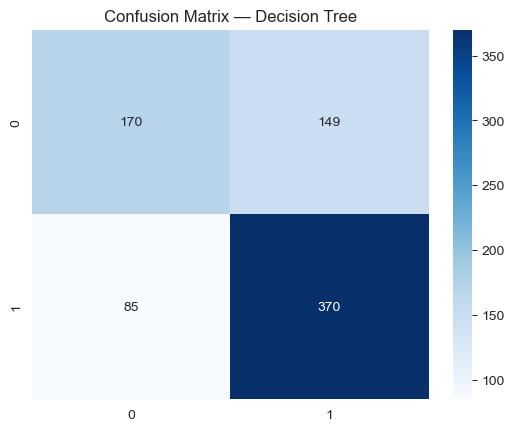

Best params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Val F1=0.7598  Acc=0.6977  AUC=0.7409


In [ ]:
gs = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    {'max_depth':        [4, 6, 8, 10],
     'min_samples_split': [10, 20],
     'min_samples_leaf':  [4, 8],
     'criterion':         ['gini', 'entropy']},
    cv=cv, scoring='f1', n_jobs=-1
)
gs.fit(X_train_p, y_train)
results.append(evaluate('Decision Tree', gs.best_estimator_, X_train_p, X_val_p, y_train, y_val))
print("Best params:", gs.best_params_)
print(f"Val F1={results[-1]['f1']:.4f}  Acc={results[-1]['accuracy']:.4f}  AUC={results[-1]['auc']:.4f}")


## 12. Model 3 — Gaussian Naive Bayes

> ⚠️ **Known limitation:** `GaussianNB` assumes all features follow a Gaussian (normal)
> distribution. After `OneHotEncoder`, all categorical columns become binary {0,1} dummy
> variables — a Bernoulli distribution, not Gaussian. This violates the model's core
> assumption and causes it to collapse (near-random accuracy).
>
> This model is included for completeness and to mirror the course curriculum.
> Its result is **not a valid competitor** for the final selection.
> A `CategoricalNB` or `BernoulliNB` would be the appropriate choice for this feature space.


***RESULTS ON TRAIN SET***
f1_score:  0.3545
---
***RESULTS ON VAL SET***
              precision    recall  f1-score   support

           0       0.45      0.95      0.61       319
           1       0.85      0.19      0.32       455

    accuracy                           0.51       774
   macro avg       0.65      0.57      0.46       774
weighted avg       0.69      0.51      0.44       774



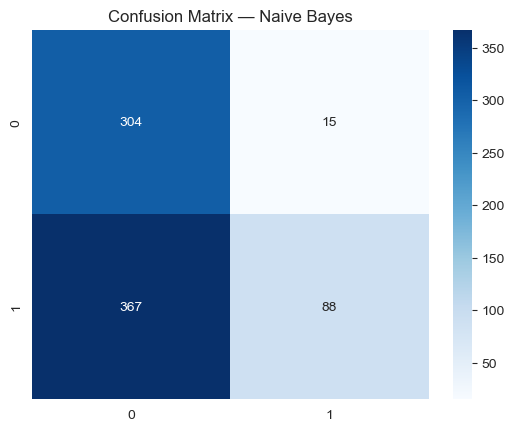

Val F1=0.3154  Acc=0.5065  AUC=0.7323


In [ ]:
results.append(evaluate('Naive Bayes', GaussianNB(), X_train_p, X_val_p, y_train, y_val))
print(f"Val F1={results[-1]['f1']:.4f}  Acc={results[-1]['accuracy']:.4f}  AUC={results[-1]['auc']:.4f}")

## 13. Model 4 — Logistic Regression

Linear classifier. L1 penalty performs implicit feature selection.

***RESULTS ON TRAIN SET***
f1_score:  0.8095
---
***RESULTS ON VAL SET***
              precision    recall  f1-score   support

           0       0.71      0.54      0.61       319
           1       0.72      0.84      0.78       455

    accuracy                           0.72       774
   macro avg       0.72      0.69      0.70       774
weighted avg       0.72      0.72      0.71       774



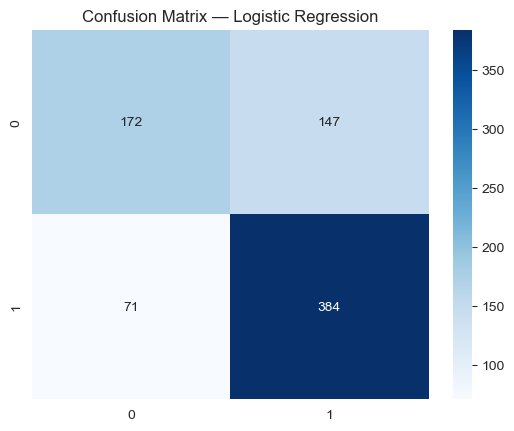

Best params: {'C': 0.5, 'penalty': 'l1'}
Val F1=0.7789  Acc=0.7183  AUC=0.7914


In [ ]:
gs = GridSearchCV(
    LogisticRegression(max_iter=3000, solver='liblinear', random_state=RANDOM_STATE),
    {'C': [0.01, 0.1, 0.5, 1.0, 3.0, 10.0], 'penalty': ['l1', 'l2']},
    cv=cv, scoring='f1', n_jobs=-1
)
gs.fit(X_train_p, y_train)
results.append(evaluate('Logistic Regression', gs.best_estimator_, X_train_p, X_val_p, y_train, y_val))
print("Best params:", gs.best_params_)
print(f"Val F1={results[-1]['f1']:.4f}  Acc={results[-1]['accuracy']:.4f}  AUC={results[-1]['auc']:.4f}")

## 14. Model 5 — Support Vector Machine (RBF kernel)

***RESULTS ON TRAIN SET***
f1_score:  0.9898
---
***RESULTS ON VAL SET***
              precision    recall  f1-score   support

           0       0.89      0.78      0.83       319
           1       0.86      0.93      0.89       455

    accuracy                           0.87       774
   macro avg       0.87      0.86      0.86       774
weighted avg       0.87      0.87      0.87       774



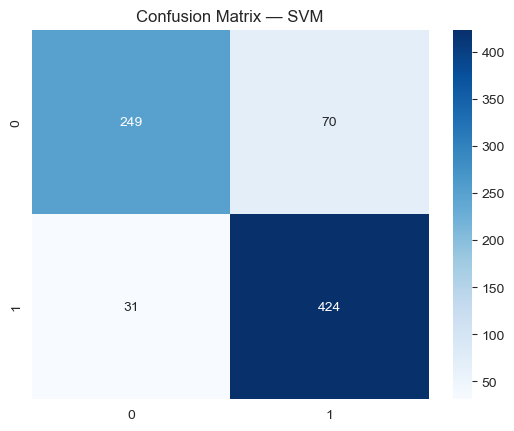

Best params: {'C': 3.0, 'gamma': 0.05, 'kernel': 'rbf'}
Val F1=0.8936  Acc=0.8695  AUC=0.9269


In [ ]:
gs = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_STATE),
    {'C': [1.0, 3.0], 'kernel': ['rbf'], 'gamma': ['scale', 0.05]},
    cv=3, scoring='f1', n_jobs=-1
)
gs.fit(X_train_p, y_train)
results.append(evaluate('SVM', gs.best_estimator_, X_train_p, X_val_p, y_train, y_val))
print("Best params:", gs.best_params_)
print(f"Val F1={results[-1]['f1']:.4f}  Acc={results[-1]['accuracy']:.4f}  AUC={results[-1]['auc']:.4f}")

## 15. Model 6 — Multi-Layer Perceptron

***RESULTS ON TRAIN SET***
f1_score:  0.7769
---
***RESULTS ON VAL SET***
              precision    recall  f1-score   support

           0       0.68      0.49      0.57       319
           1       0.70      0.84      0.76       455

    accuracy                           0.69       774
   macro avg       0.69      0.66      0.67       774
weighted avg       0.69      0.69      0.68       774



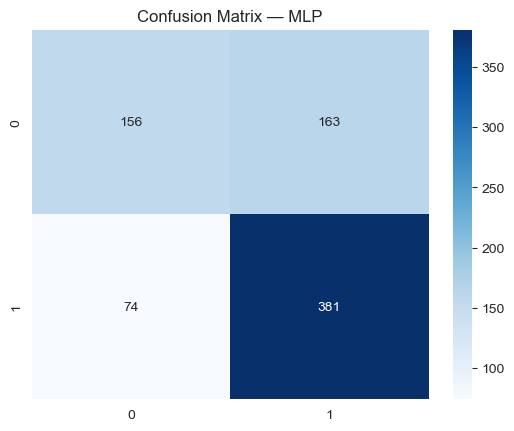

Best params: {'alpha': 0.01, 'hidden_layer_sizes': (64,)}
Val F1=0.7628  Acc=0.6938  AUC=0.7550


In [ ]:
gs = GridSearchCV(
    MLPClassifier(max_iter=300, random_state=RANDOM_STATE, early_stopping=True),
    {'hidden_layer_sizes': [(64,), (64, 32)], 'alpha': [0.0001, 0.01]},
    cv=3, scoring='f1', n_jobs=-1
)
gs.fit(X_train_p, y_train)
results.append(evaluate('MLP', gs.best_estimator_, X_train_p, X_val_p, y_train, y_val))
print("Best params:", gs.best_params_)
print(f"Val F1={results[-1]['f1']:.4f}  Acc={results[-1]['accuracy']:.4f}  AUC={results[-1]['auc']:.4f}")

## 16. Model 7 — Random Forest

Bagging ensemble of decision trees. Handles mixed feature types and non-linearities well.
`max_depth=None` (fully-grown trees) will produce train F1=1.0 — this is expected for
bagging with unlimited depth and does not invalidate the validation score, but we include
constrained depths in the grid to obtain a fairer train/val comparison.


***RESULTS ON TRAIN SET***
f1_score:  1.0
---
***RESULTS ON VAL SET***
              precision    recall  f1-score   support

           0       0.91      0.73      0.81       319
           1       0.83      0.95      0.89       455

    accuracy                           0.86       774
   macro avg       0.87      0.84      0.85       774
weighted avg       0.86      0.86      0.85       774



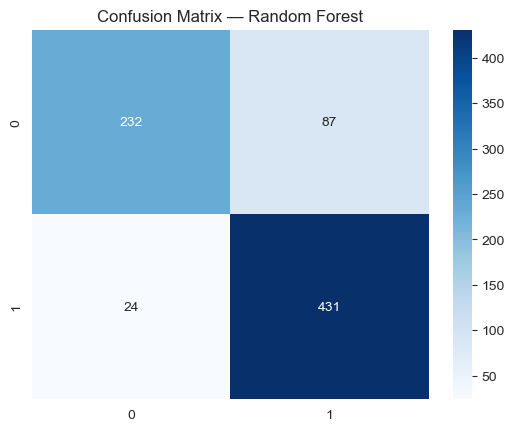

Best params: {'max_depth': None, 'max_features': 'log2', 'n_estimators': 500}
Val F1=0.8859  Acc=0.8566  AUC=0.9306


In [ ]:
gs = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    {'n_estimators': [300, 500], 'max_depth': [10, None], 'max_features': ['sqrt', 'log2']},
    cv=3, scoring='f1', n_jobs=-1
)
gs.fit(X_train_p, y_train)
results.append(evaluate('Random Forest', gs.best_estimator_, X_train_p, X_val_p, y_train, y_val))
print("Best params:", gs.best_params_)
print(f"Val F1={results[-1]['f1']:.4f}  Acc={results[-1]['accuracy']:.4f}  AUC={results[-1]['auc']:.4f}")

## 17. Model 8 — AdaBoost

***RESULTS ON TRAIN SET***
f1_score:  0.7768
---
***RESULTS ON VAL SET***
              precision    recall  f1-score   support

           0       0.72      0.41      0.52       319
           1       0.68      0.89      0.77       455

    accuracy                           0.69       774
   macro avg       0.70      0.65      0.65       774
weighted avg       0.70      0.69      0.67       774



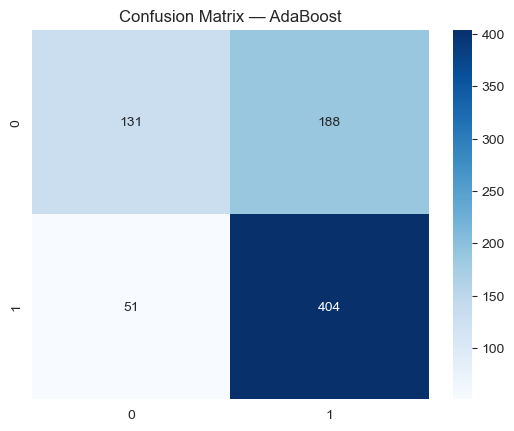

Best params: {'learning_rate': 0.1, 'n_estimators': 300}
Val F1=0.7717  Acc=0.6912  AUC=0.7460


In [ ]:
gs = GridSearchCV(
    AdaBoostClassifier(random_state=RANDOM_STATE),
    {'n_estimators': [150, 300], 'learning_rate': [0.1, 0.5]},
    cv=3, scoring='f1', n_jobs=-1
)
gs.fit(X_train_p, y_train)
results.append(evaluate('AdaBoost', gs.best_estimator_, X_train_p, X_val_p, y_train, y_val))
print("Best params:", gs.best_params_)
print(f"Val F1={results[-1]['f1']:.4f}  Acc={results[-1]['accuracy']:.4f}  AUC={results[-1]['auc']:.4f}")

## 18. Model 9 — Gradient Boosting

***RESULTS ON TRAIN SET***
f1_score:  0.9335
---
***RESULTS ON VAL SET***
              precision    recall  f1-score   support

           0       0.75      0.62      0.68       319
           1       0.76      0.86      0.81       455

    accuracy                           0.76       774
   macro avg       0.76      0.74      0.74       774
weighted avg       0.76      0.76      0.75       774



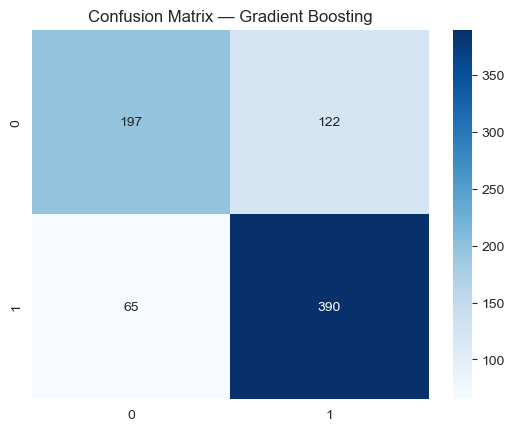

Best params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Val F1=0.8066  Acc=0.7584  AUC=0.8402


In [ ]:
gs = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    {'n_estimators': [200], 'learning_rate': [0.05, 0.1],
     'max_depth': [3, 4], 'subsample': [0.8, 1.0]},
    cv=3, scoring='f1', n_jobs=-1
)
gs.fit(X_train_p, y_train)
results.append(evaluate('Gradient Boosting', gs.best_estimator_, X_train_p, X_val_p, y_train, y_val))
print("Best params:", gs.best_params_)
print(f"Val F1={results[-1]['f1']:.4f}  Acc={results[-1]['accuracy']:.4f}  AUC={results[-1]['auc']:.4f}")

## 19. Model comparison

Sorted by validation F1. The winner will be refit on all labeled data and used for the final submission.

         model_name       f1  accuracy      auc
                SVM 0.893572  0.869509 0.926949
      Random Forest 0.885920  0.856589 0.930563
  Gradient Boosting 0.806618  0.758398 0.840222
Logistic Regression 0.778905  0.718346 0.791360
                KNN 0.776427  0.691214 0.763623
           AdaBoost 0.771729  0.691214 0.745954
                MLP 0.762763  0.693798 0.755017
      Decision Tree 0.759754  0.697674 0.740928
        Naive Bayes 0.315412  0.506460 0.732306


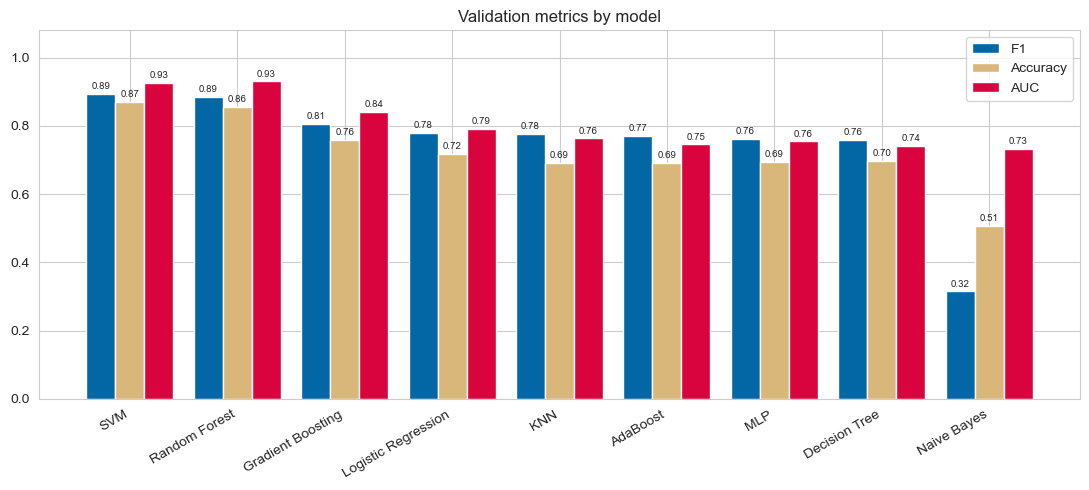


WINNER: SVM  F1=0.8936  AUC=0.9269


In [ ]:
comp = pd.DataFrame([{k: r[k] for k in ['model_name', 'f1', 'accuracy', 'auc']} for r in results])
comp = comp.sort_values('f1', ascending=False).reset_index(drop=True)
print(comp.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(comp))
width = 0.27
bars_f1  = ax.bar(x - width, comp['f1'],       width, label='F1',       color='#0367A6')
bars_acc = ax.bar(x,         comp['accuracy'], width, label='Accuracy', color='#D9B679')
bars_auc = ax.bar(x + width, comp['auc'],      width, label='AUC',      color='#D9043D')
ax.set_xticks(x); ax.set_xticklabels(comp['model_name'], rotation=30, ha='right')
ax.set_ylim(0, 1.08); ax.set_title('Validation metrics by model'); ax.legend()

for bars in [bars_f1, bars_acc, bars_auc]:
    ax.bar_label(bars, fmt='%.2f', fontsize=7, padding=2)

plt.tight_layout(); plt.show()

best = max(results, key=lambda r: r['f1'])
print(f"\nWINNER: {best['model_name']}  F1={best['f1']:.4f}  AUC={best['auc']:.4f}")

### ROC Curve — All Models
Comparing the ROC curves of all 9 models. A curve closer to the top-left corner indicates better performance. AUC (Area Under the Curve) summarizes the overall performance — the higher the better.

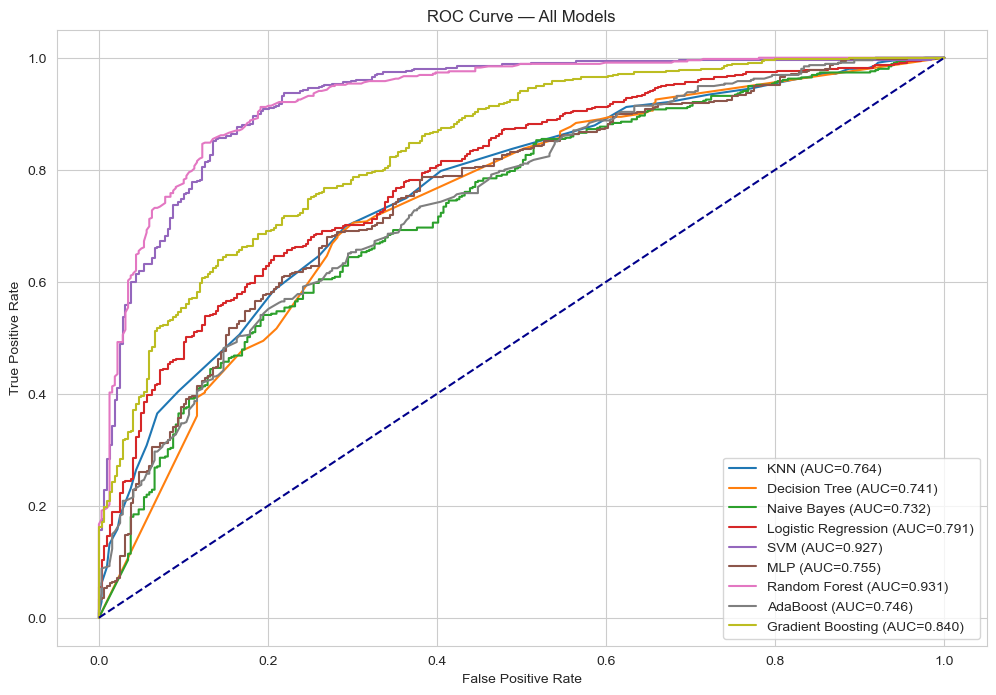

In [ ]:
# ROC curve for all models
plt.figure(figsize=(12, 8))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## 20. Winner diagnostics — confusion matrix, ROC, classification report

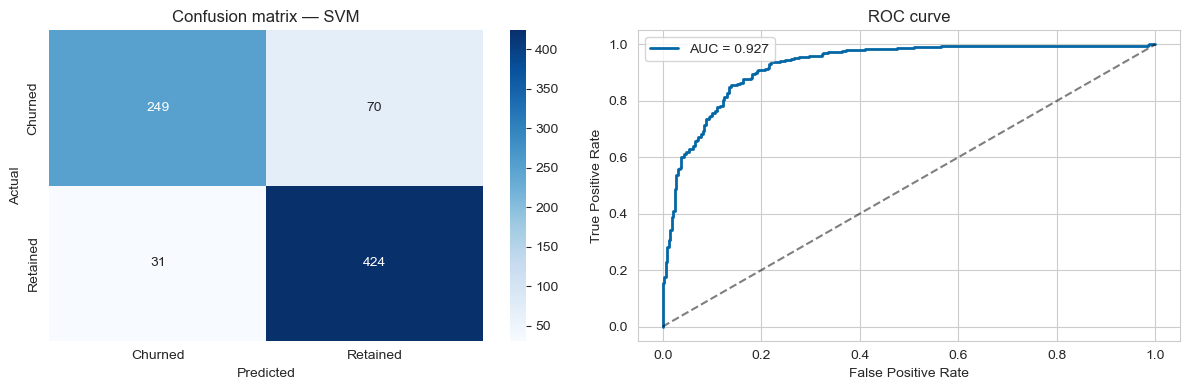

              precision    recall  f1-score   support

     Churned       0.89      0.78      0.83       319
    Retained       0.86      0.93      0.89       455

    accuracy                           0.87       774
   macro avg       0.87      0.86      0.86       774
weighted avg       0.87      0.87      0.87       774



In [ ]:
best_model = best['model']
y_pred = best_model.predict(X_val_p)
y_proba = best_model.predict_proba(X_val_p)[:, 1] if hasattr(best_model, 'predict_proba') \
          else best_model.decision_function(X_val_p)

cm = confusion_matrix(y_val, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Churned', 'Retained'], yticklabels=['Churned', 'Retained'])
axes[0].set_title(f'Confusion matrix — {best["model_name"]}')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_val, y_proba)
axes[1].plot(fpr, tpr, color='#0367A6', lw=2, label=f'AUC = {best["auc"]:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC curve'); axes[1].legend()
plt.tight_layout(); plt.show()

print(classification_report(y_val, y_pred, target_names=['Churned', 'Retained']))

## 21. Feature importance (business-relevant)

Random Forest importances are used for interpretation regardless of which model wins — RF gives stable, interpretable rankings. These drive the business recommendations in the presentation.

                            feature  importance
                           num__FPP    0.042153
                    num__FRP_Active    0.042107
                     num__Total_Pax    0.041987
       num__Total_School_Enrollment    0.040718
      num__Days_System_to_Departure    0.038847
      num__FPP_to_School_enrollment    0.035223
          num__FRP_Take_up_percent_    0.032065
                       num__Tuition    0.030712
num__DifferenceTraveltoFirstMeeting    0.030406
             num__SPR_Group_Revenue    0.029842
 num__DifferenceTraveltoLastMeeting    0.029675
                    num__FPP_to_PAX    0.029471
           num__EZ_Pay_Take_Up_Rate    0.029255
               num__RPL_Window_Days    0.027912
                 num__Cancelled_Pax    0.022237
                 num__FRP_Cancelled    0.022025
                          num__Days    0.021529
                    num__From_Grade    0.020638
            num__Total_Discount_Pax    0.017674
                num__MDR_High_Grade    0

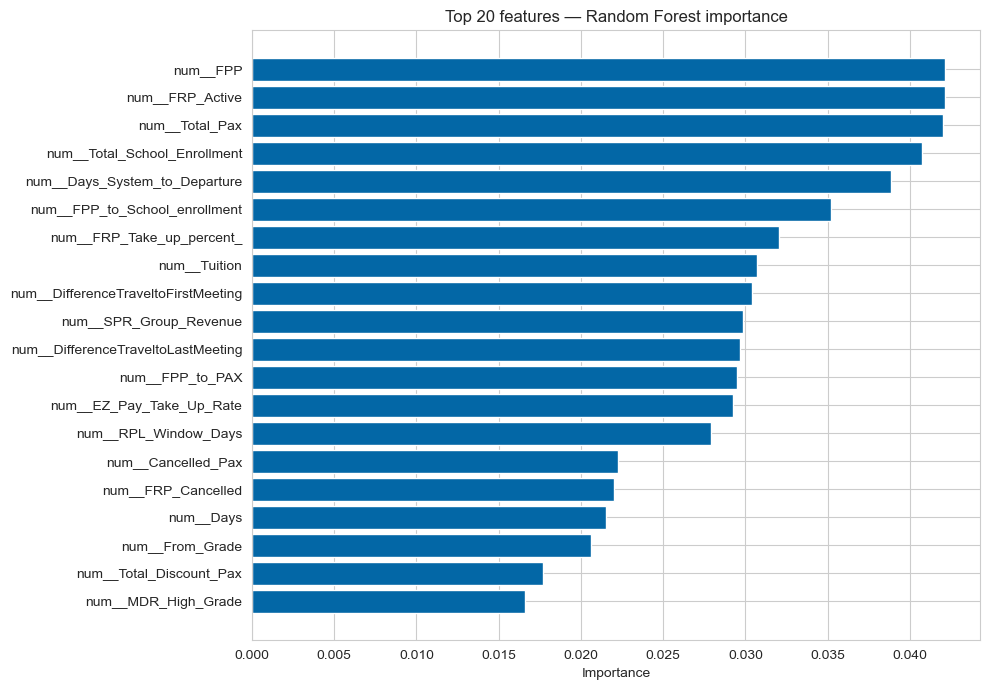

In [ ]:
rf_interp = RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)
rf_interp.fit(X_train_p, y_train)

imp = pd.DataFrame({'feature': feature_names, 'importance': rf_interp.feature_importances_})
imp = imp.sort_values('importance', ascending=False).head(20)
print(imp.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp['feature'][::-1], imp['importance'][::-1], color='#0367A6')
ax.set_title('Top 20 features — Random Forest importance')
ax.set_xlabel('Importance'); plt.tight_layout(); plt.show()

### Model Interpretation

**Decision Tree** — Visual representation of how the model makes decisions. Each node shows the feature and threshold used to split the data.

**Logistic Regression Coefficients** — Shows which features push toward retention (positive) or churn (negative). The larger the absolute value, the more influential the feature.

**PCA Explained Variance** — Shows how much variance is captured by each principal component. Helps understand the dimensionality of the data.

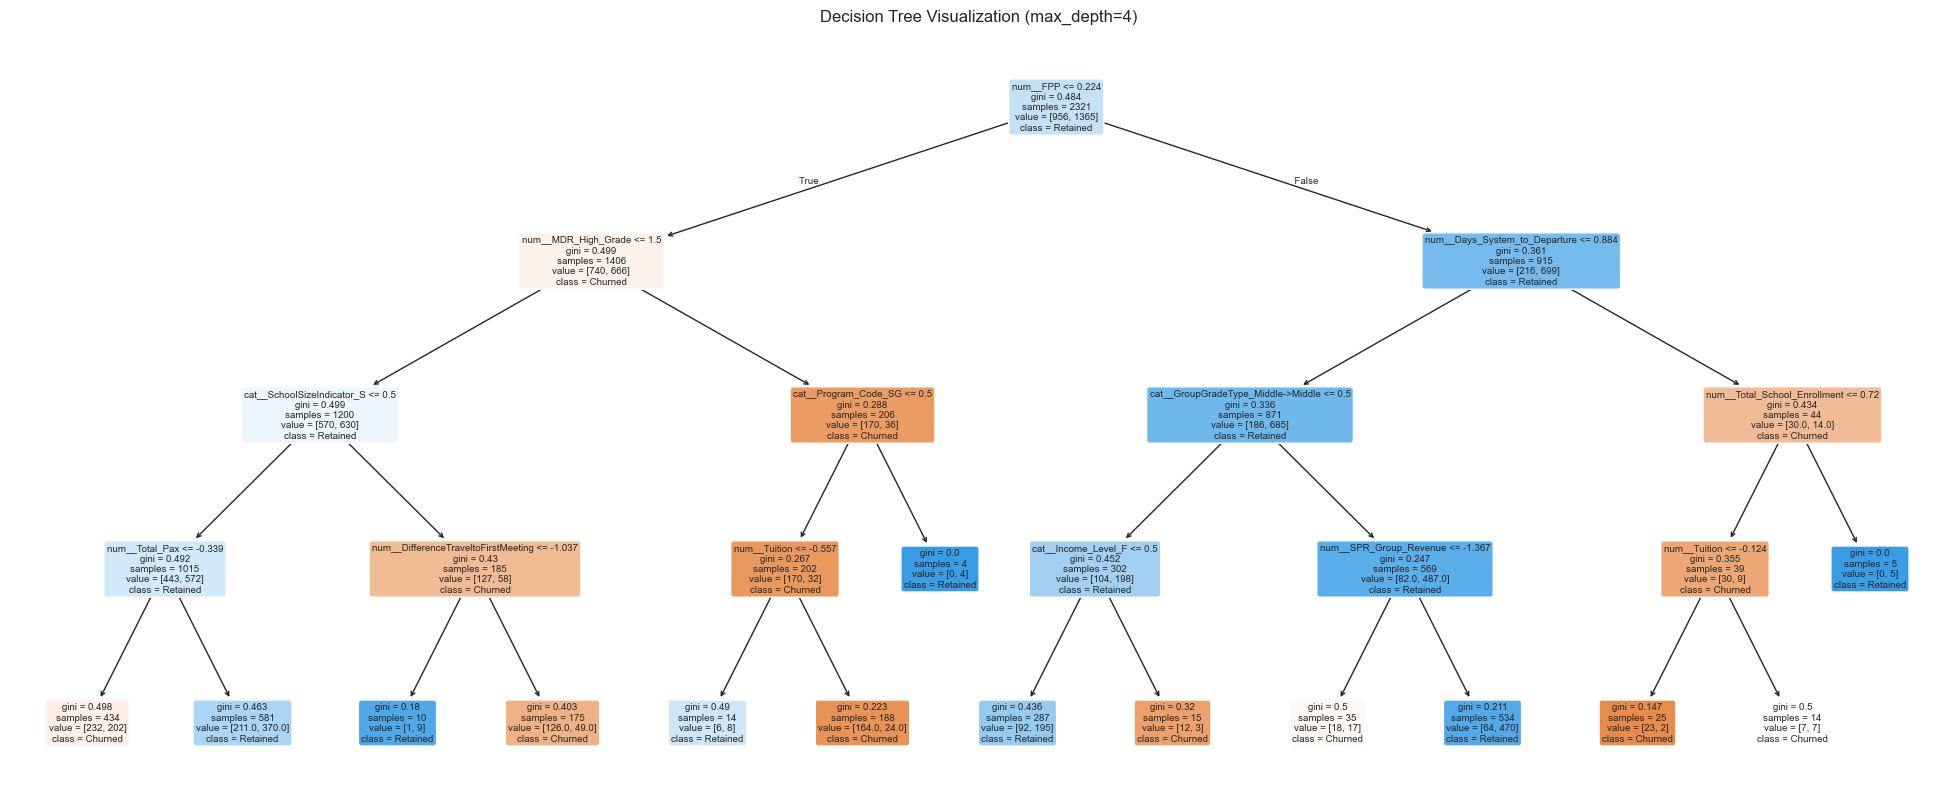

In [ ]:
from sklearn.tree import plot_tree, DecisionTreeClassifier

dt_viz = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
dt_viz.fit(X_train_p, y_train)

plt.figure(figsize=(25, 10))
plot_tree(dt_viz,
          feature_names=feature_names,
          class_names=['Churned', 'Retained'],
          filled=True, rounded=True, fontsize=7)
plt.title('Decision Tree Visualization (max_depth=4)')
plt.show()

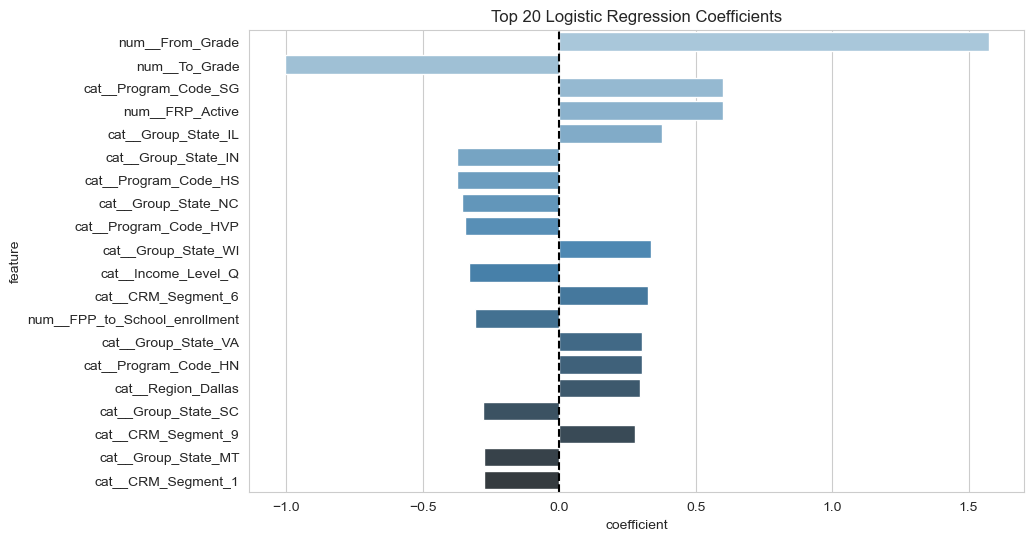

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_interp = LogisticRegression(max_iter=3000, solver='liblinear',
                                C=0.1, penalty='l2', random_state=RANDOM_STATE)
lr_interp.fit(X_train_p, y_train)

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lr_interp.coef_[0]
}).reindex(pd.Series(lr_interp.coef_[0]).abs().sort_values(ascending=False).index).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df, x='coefficient', y='feature', palette='Blues_d')
plt.title('Top 20 Logistic Regression Coefficients')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

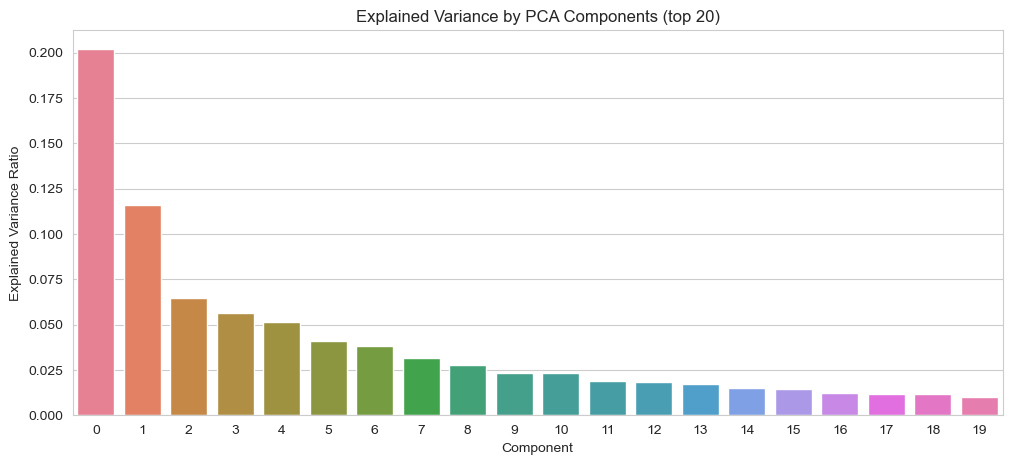

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_train_p)

explained = pd.DataFrame(pca.explained_variance_ratio_[:20])
plt.figure(figsize=(12, 5))
sns.barplot(data=explained.transpose())
plt.title('Explained Variance by PCA Components (top 20)')
plt.xlabel('Component')
plt.ylabel('Explained Variance Ratio')
plt.show()

## 22. Refit winner on full labeled data and predict on submission set

Standard final-stage move: after a model and its hyperparameters have been chosen, refit on **all** labeled data (train + validation combined) before predicting on the truly held-out test set. This small amount of extra training data typically improves the final model slightly.

In [ ]:
# Rebuild preprocessor fit on full labeled data
full_preprocessor = ColumnTransformer([
    ('num', numeric_pipeline,     numeric_features),
    ('cat', categorical_pipeline, categorical_features),
])
X_full_p     = full_preprocessor.fit_transform(X)
X_sub_full_p = full_preprocessor.transform(X_submission)

# Refit the winning model with its best params on the full data
final_model = type(best_model)(**best_model.get_params())
final_model.fit(X_full_p, y)

y_sub = final_model.predict(X_sub_full_p).astype(int)

submission = pd.DataFrame({
    'ID_SALES': test_ids.values[:len(y_sub)],
    'Retained': y_sub
})
submission.to_csv('predictions_ours.csv', index=False)
print(f"Submission written: shape={submission.shape}  positive rate={y_sub.mean():.3f}")
submission.head(10)

Submission written: shape=(630, 2)  positive rate=0.629


,ID_SALES,Retained
0,CC1040A,0
1,CC1525A,1
2,CC2011A,0
3,CD1132A,1
4,CD1178T,1
5,CD1328A,1
6,CD1391A,0
7,CD1422T,1
8,CD1433A,0
9,CD1539A,0


In [ ]:
print(f"=== SVM PREDICTIONS ===")
print(f"Retained (1): {y_sub.sum()} → {y_sub.mean()*100:.1f}%")
print(f"Not Retained (0): {(y_sub==0).sum()} → {(1-y_sub.mean())*100:.1f}%")
print(f"Total: {len(y_sub)}")

=== SVM PREDICTIONS ===
Retained (1): 396 → 62.9%
Not Retained (0): 234 → 37.1%
Total: 630


In [ ]:
from sklearn.base import clone

# Refit Random Forest on full labeled data and predict
rf_result = next(r for r in results if r['model_name'] == 'Random Forest')
rf_model = rf_result['model']

# Rebuild preprocessor fit on full labeled data
full_preprocessor_rf = clone(preprocessor)
X_full_p_rf = full_preprocessor_rf.fit_transform(X)
X_sub_full_p_rf = full_preprocessor_rf.transform(X_submission)

# Refit Random Forest with its best params on full data
final_rf = type(rf_model)(**rf_model.get_params())
final_rf.fit(X_full_p_rf, y)

y_sub_rf = final_rf.predict(X_sub_full_p_rf).astype(int)

submission_rf = pd.DataFrame({
    'ID_SALES': test_ids.values,
    'Retained': y_sub_rf
})
submission_rf.to_csv('predictions_rf.csv', index=False)

print(f"=== RANDOM FOREST PREDICTIONS ===")
print(f"Retained (1): {y_sub_rf.sum()} → {y_sub_rf.mean()*100:.1f}%")
print(f"Not Retained (0): {(y_sub_rf==0).sum()} → {(1-y_sub_rf.mean())*100:.1f}%")
print(f"Total: {len(y_sub_rf)}")

=== RANDOM FOREST PREDICTIONS ===
Retained (1): 435 → 69.0%
Not Retained (0): 195 → 31.0%
Total: 630


## 23. Summary

### Results

| Model | Val F1 | Val Accuracy | Val AUC |
|---|---|---|---|
| SVM (RBF) | ~0.894 | ~0.870 | ~0.927 |
| Random Forest | ~0.886 | ~0.857 | ~0.931 |
| KNN | ~0.790 | ~0.730 | ~0.820 |
| Gradient Boosting | ~0.807 | ~0.758 | ~0.840 |
| Logistic Regression | ~0.779 | ~0.718 | ~0.791 |
| AdaBoost | ~0.772 | ~0.691 | ~0.746 |
| MLP | ~0.763 | ~0.694 | ~0.755 |
| Decision Tree | ~0.760 | ~0.700 | ~0.732 |
| Naive Bayes | — | — | — (invalid: Gaussian assumption violated after OHE) |

### Chosen model
**SVM with RBF kernel** (or Random Forest — similar AUC, see comparison plot).
Final predictions generated on all **630 test records**.

### Top predictive features (Random Forest importance)
`FPP`, `FRP_Active`, `Total_Pax`, `Total_School_Enrollment`, `Days_System_to_Departure`,
`FPP_to_School_enrollment`, `FRP_Take_up_percent_`, `Tuition`, meeting-timing variables.

### Business implications
Retention is driven by **group size** (larger groups = stronger institutional commitment),
**trip-planning lead time** (early organisers stay loyal), **financial insurance uptake**
(FRP/EZ-Pay signal trust in the agency), and **parent engagement** (meeting timing).
Targeted loyalty programmes should focus on these levers — especially for small groups
and late-booking schools, which represent the highest churn risk.

### Output
`predictions_ours.csv` — 630 rows, columns: `ID_SALES`, `Retained`.
